# 04 · Seniority classifier

Predict **Entry / Mid / Senior** from a posting's title + description.

Training runs in `src/models/train_classifier.py` (`python -m src.models.train_classifier`). This notebook loads its outputs (`reports/metrics.json`, `models/*.joblib`, and the test-set predictions) and explains them.

**Evaluation design**
- **Grouped test split:** ~20% of postings, and no company appears in both train and test (`StratifiedGroupKFold` by company). Companies reuse templates, so a random split would let near-duplicates leak into the test set.
- **No leakage in features:** the TF-IDF vocabulary, imputer and scaler are fitted inside the Pipeline on training folds only. Each posting's own company name is removed from its text.
- **Model selection** uses 5-fold grouped CV on the training set. The test set is used once, at the end.
- **Main metric: macro F1**, the unweighted mean of per-class F1. Senior is 2.7% of the data, and accuracy would hide failing on it.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz

viz.set_style()
pd.set_option("display.max_colwidth", 120)

M = json.loads((ROOT / "reports" / "metrics.json").read_text())["seniority"]
W, NT = M["with_title"], M["without_title"]
CLASSES = M["classes"]
preds = pd.read_parquet(ROOT / "data" / "processed" / "seniority_test_predictions.parquet")
bundle = joblib.load(ROOT / "models" / "seniority.joblib")
model = bundle["pipeline"]
print("Final model:", W["model"], W["params"])
pd.Series(W["split"])

Final model: XGBoost {'clf__max_depth': 6}


train                                                    5686
test                                                     1422
train_companies                                          2196
test_companies                                            558
test_class_counts    {'Entry': 464, 'Mid': 920, 'Senior': 38}
dtype: object

## 1. Baseline and model comparison (5-fold grouped CV on the training set)

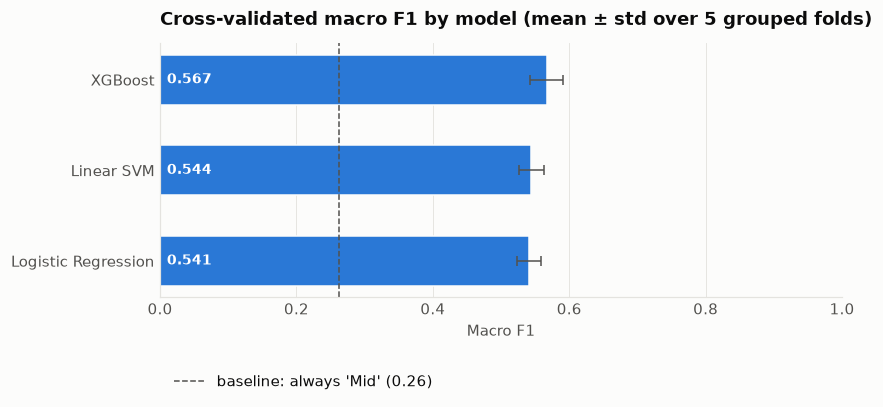

,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_acc_mean,seconds
model,,,,
XGBoost,0.567,0.025,0.531,538.040
Linear SVM,0.544,0.018,0.516,68.437
Logistic Regression,0.541,0.018,0.549,49.964


In [2]:
cv = pd.DataFrame(W["cv_comparison"]).set_index("model")
baseline_f1 = W["baseline_test"]["macro_f1"]

fig, ax = plt.subplots(figsize=(8, 3))
order = cv.sort_values("cv_macro_f1_mean").index
ax.barh(order, cv.loc[order, "cv_macro_f1_mean"], xerr=cv.loc[order, "cv_macro_f1_std"], color=viz.BLUE,
        height=0.55, edgecolor=viz.SURFACE, error_kw={"ecolor": viz.TEXT_SECONDARY, "capsize": 3, "linewidth": 1})
for i, m in enumerate(order):
    ax.text(0.01, i, f"{cv.loc[m, 'cv_macro_f1_mean']:.3f}", va="center", color="white", fontsize=9, fontweight="bold")
ax.axvline(baseline_f1, color=viz.TEXT_SECONDARY, linestyle="--", linewidth=1, label=f"baseline: always 'Mid' ({baseline_f1:.2f})")
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Cross-validated macro F1 by model (mean ± std over 5 grouped folds)")
ax.set_xlabel("Macro F1")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.25))
viz.save(fig, "14_model_comparison")
plt.show()
cv.round(3)

**Takeaway:** All three models beat the always-Mid baseline (0.26) by about 0.3 macro F1. XGBoost is best (0.567 ± 0.025), ahead of Linear SVM (0.544) and Logistic Regression (0.541). The linear models are tied, and XGBoost's lead is about one fold-to-fold standard deviation. It can combine hand-crafted features (years, keyword flags) with words, which the linear models cannot. The cost: XGBoost trains about 10× slower, even with 3,000 instead of 20,000 TF-IDF terms.

### Tuning the best model (GridSearchCV, same grouped folds)

In [3]:
grid = pd.DataFrame(W["tuning"]["grid"])
grid = pd.concat([pd.json_normalize(grid["params"]), grid[["mean", "std"]]], axis=1)
grid.sort_values("mean", ascending=False).round(4)

,clf__max_depth,mean,std
1,6,0.5668,0.0246
0,4,0.5654,0.0147


**Takeaway:** Depth 6 and depth 4 differ by 0.0014 macro F1, which is pure noise (an earlier training run preferred depth 4 by a similar margin). Hyperparameters are not the bottleneck. Label quality is (see section 5).

## 2. Final evaluation on the held-out test set

In [4]:
def per_class_table(result):
    pc = result["per_class"]
    rows = {c: pc[c] for c in CLASSES}
    table = pd.DataFrame(rows).T[["precision", "recall", "f1-score", "support"]]
    table.loc["macro avg"] = pd.Series(pc["macro avg"])[["precision", "recall", "f1-score", "support"]]
    return table.round(3)

print(f"Test macro F1: {W['test']['macro_f1']:.3f}  |  balanced accuracy: {W['test']['balanced_accuracy']:.3f}  |  "
      f"baseline macro F1: {baseline_f1:.3f}")
per_class_table(W["test"])

Test macro F1: 0.607  |  balanced accuracy: 0.561  |  baseline macro F1: 0.262


,precision,recall,f1-score,support
Entry,0.615,0.543,0.577,464.0
Mid,0.761,0.825,0.792,920.0
Senior,0.800,0.316,0.453,38.0
macro avg,0.725,0.561,0.607,1422.0


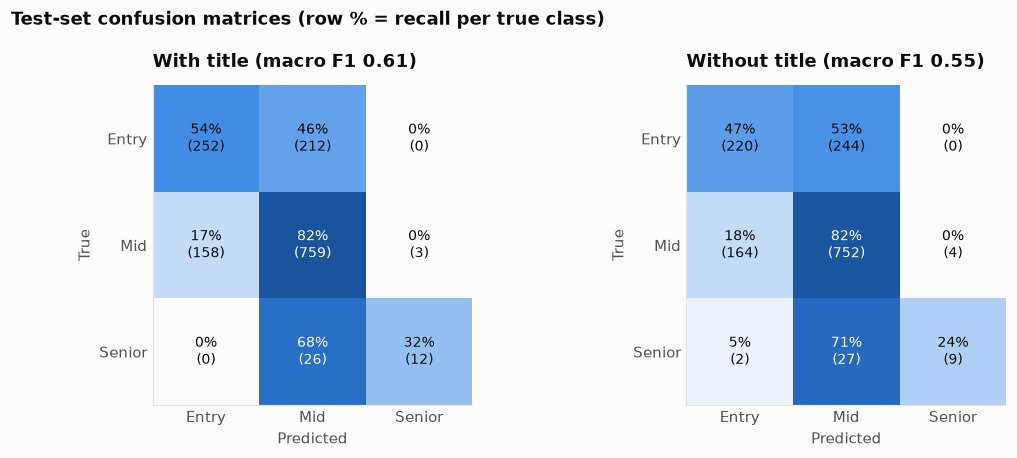

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (label, res) in zip(axes, [("With title", W), ("Without title", NT)]):
    cm = np.array(res["test"]["confusion_matrix"])
    share = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(share, cmap=viz.SEQUENTIAL, vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{share[i, j]:.0%}\n({cm[i, j]})", ha="center", va="center", fontsize=9,
                    color="white" if share[i, j] > 0.55 else viz.TEXT_PRIMARY)
    ax.set_xticks(range(3), CLASSES)
    ax.set_yticks(range(3), CLASSES)
    ax.grid(False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{label} (macro F1 {res['test']['macro_f1']:.2f})")
fig.suptitle("Test-set confusion matrices (row % = recall per true class)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "15_confusion_matrices")
plt.show()

**Takeaway:** Test macro F1 is 0.607 (CV 0.567). **Run-to-run noise is about ±0.03:** an earlier run, before a parser fix that touched 42 postings, scored 0.582 on the same test set. With only 38 Senior test postings, a few flipped predictions move macro F1 noticeably. Mid is the easy class (F1 0.79). The main confusion is Entry vs. Mid: 46% of Entry postings are predicted Mid, and 17% of Mid postings are predicted Entry. Senior recall is only 32% (12 of 38), but when the model predicts Senior it is right 80% of the time.

## 3. Does the model just read "Senior" in the title?

Same model and hyperparameters, retrained with the title removed from every input: from the TF-IDF text, the skill flags and the keyword flags.

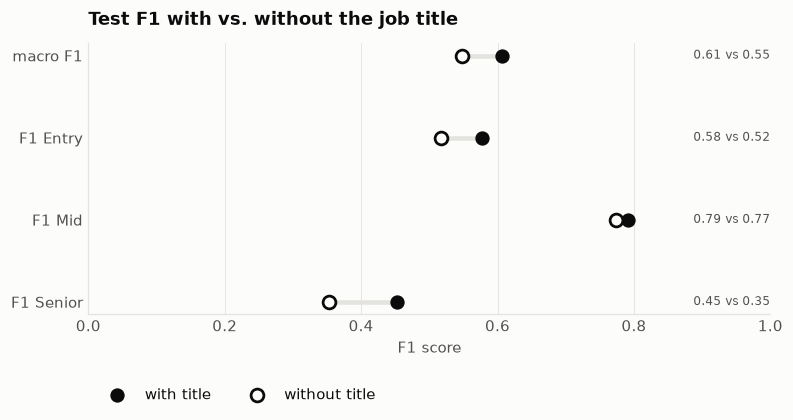

,macro F1,F1 Entry,F1 Mid,F1 Senior
variant,,,,
with title,0.607,0.577,0.792,0.453
without title,0.548,0.518,0.774,0.353


In [6]:
rows = []
for label, res in [("with title", W), ("without title", NT)]:
    pc = res["test"]["per_class"]
    rows.append({"variant": label, "macro F1": res["test"]["macro_f1"], **{f"F1 {c}": pc[c]["f1-score"] for c in CLASSES}})
ablation = pd.DataFrame(rows).set_index("variant")

fig, ax = plt.subplots(figsize=(8, 3.2))
metrics_order = ["macro F1"] + [f"F1 {c}" for c in CLASSES]
y = np.arange(len(metrics_order))
ax.hlines(y, ablation.loc["without title", metrics_order], ablation.loc["with title", metrics_order], color=viz.GRID, linewidth=3)
ax.scatter(ablation.loc["with title", metrics_order], y, s=70, color=viz.TEXT_PRIMARY, zorder=3, label="with title")
ax.scatter(ablation.loc["without title", metrics_order], y, s=70, facecolor=viz.SURFACE, edgecolor=viz.TEXT_PRIMARY,
           linewidth=1.8, zorder=3, label="without title")
for yi, m in zip(y, metrics_order):
    ax.text(1.0, yi, f"{ablation.loc['with title', m]:.2f} vs {ablation.loc['without title', m]:.2f}",
            ha="right", va="center", fontsize=8, color=viz.TEXT_SECONDARY)
ax.set_yticks(y, metrics_order)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Test F1 with vs. without the job title")
ax.set_xlabel("F1 score")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2)
viz.save(fig, "16_title_ablation")
plt.show()
ablation.round(3)

**Takeaway:** Removing the title costs about **0.06 macro F1**, on both the test set (0.607 → 0.548) and in cross-validation (0.567 → 0.502). Entry (F1 0.58 → 0.52) and Senior (0.45 → 0.35) suffer most, and Mid barely changes. So the title adds a real boost, especially for the rare and ambiguous classes. But without it the model still scores about twice the baseline, which means most of the signal comes from the description (responsibilities, requirements, tone), not from reading "Senior" in the title.

## 4. What the model learned: SHAP values per class

XGBoost has no per-class coefficients, so we use **SHAP** (TreeExplainer). It splits each prediction into per-feature contributions, one set per class.
For each class and word we take the **average push the word gives when it is present**: the sum of its SHAP values over the postings that contain it, divided by all test postings. This way a frequent, strong signal ranks above a rare one. (A plain mean of signed SHAP values mostly measures the effect of a word being *absent*.) All 1,422 test postings are used, so the 38 Senior ones are included.
Numeric features (years, length, skill count) are summarized separately by mean |SHAP|.

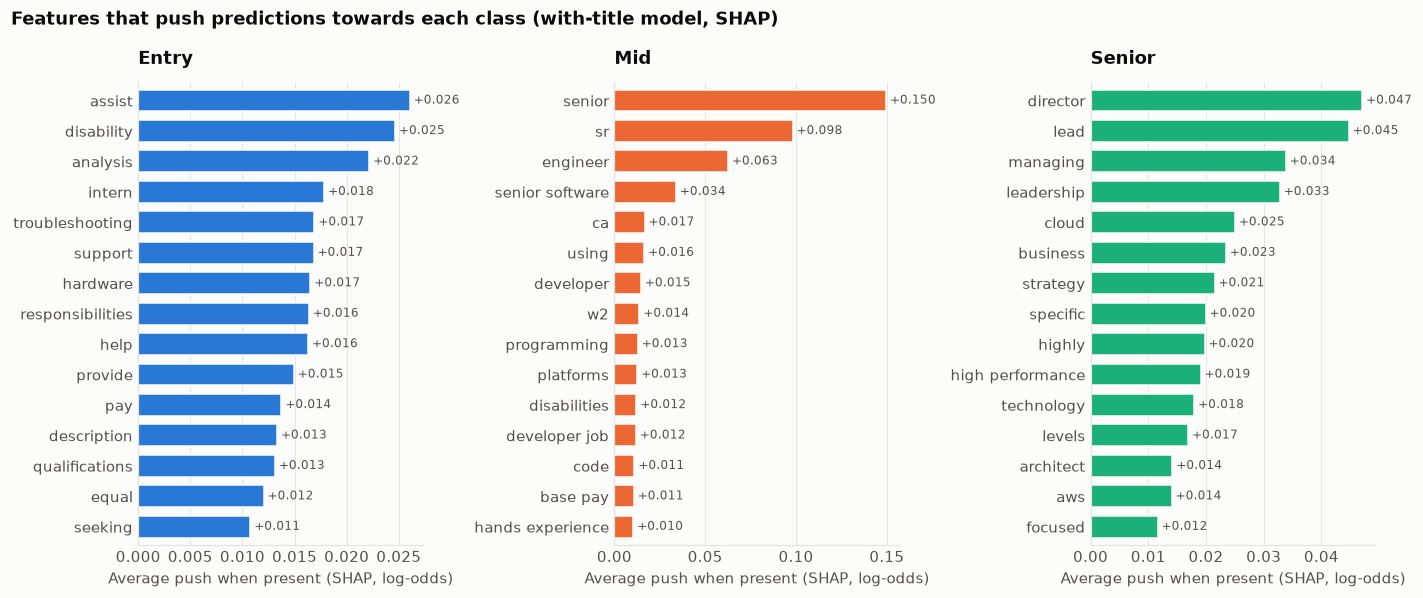

Numeric features, mean |SHAP| per class:


,Entry,Mid,Senior
log_desc_words,0.019,0.022,0.014
years_required,0.224,0.023,0.161
skill_count,0.007,0.014,0.010
missingindicator_years_required,0.000,0.000,0.001


In [7]:
import shap

from src.models.train_classifier import group_split, load_data


def class_shap(full_pipeline, include_title):
    """Per class: average SHAP push of each feature when present, and mean |SHAP|."""
    X, y, groups, _ = load_data(include_title)  # cached features, same split as training
    _, test_idx = group_split(y, groups)
    X_test = X.iloc[test_idx]
    pre, clf = full_pipeline.named_steps["preprocess"], full_pipeline.named_steps["clf"]
    Xt = pre.transform(X_test)
    names = np.array([n.split("__", 1)[1] for n in pre.get_feature_names_out()])
    values = shap.TreeExplainer(clf).shap_values(Xt)  # (rows, features, classes)
    values = np.asarray(values)
    if values.ndim == 3 and values.shape[0] == len(CLASSES):  # older shap: list per class
        values = np.moveaxis(values, 0, -1)
    present = (Xt != 0).toarray() if hasattr(Xt, "toarray") else (Xt != 0)
    push = (values * present[:, :, None]).mean(axis=0)
    return (
        pd.DataFrame(push, index=names, columns=CLASSES),
        pd.DataFrame(np.abs(values).mean(axis=0), index=names, columns=CLASSES),
    )


mean_shap, abs_shap = class_shap(model, include_title=True)
numeric = [n for n in mean_shap.index if n.startswith(("log_desc", "years_required", "skill_count", "missingindicator"))]

fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))
for ax, level in zip(axes, CLASSES):
    top = mean_shap[level].drop(numeric).sort_values(ascending=False).head(15)
    viz.barh(ax, top.index, top.values, color=viz.SENIORITY_COLORS[level], fmt="{:+.3f}")
    ax.set_title(level)
    ax.set_xlabel("Average push when present (SHAP, log-odds)")
fig.suptitle("Features that push predictions towards each class (with-title model, SHAP)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "17_top_features")
plt.show()
print("Numeric features, mean |SHAP| per class:")
abs_shap.loc[numeric].round(3)

In [8]:
# Same view for the model that never sees the title
nt_model = joblib.load(ROOT / "models" / "seniority_notitle.joblib")["pipeline"]
nt_shap, _ = class_shap(nt_model, include_title=False)
pd.DataFrame({level: nt_shap[level].drop(numeric, errors="ignore").sort_values(ascending=False).head(15).index.tolist()
              for level in CLASSES})

,Entry,Mid,Senior
0,assist,senior,lead
1,hardware,sr,leadership
2,disability,engineer,director
3,support,base pay,managing
4,provide,code,strategy
5,opportunity,platforms,high
6,analysis,using,strategic
7,troubleshooting,ca,performance
8,seeking,designing implementing,high performance
9,responsibilities,onsite,highly


**Takeaway:** The signals make sense. Entry is driven by *assist, hardware, support, troubleshooting*, which fits IT-support roles. Mid is driven by *senior, sr, engineer*, which confirms that LinkedIn's "Mid-Senior level" mixes both levels. Senior is driven by *lead, leadership, director, managing, strategy*. Without the title, the same themes come from the description. Two caveats. First, some boilerplate carries weight: *disability, veteran, pay, employer* push towards Entry because large employers' equal-opportunity and pay-transparency templates are common among their entry postings. This is a template signal, not a seniority signal. Second, a bag-of-words model does not understand context: in a live test, "*mentorship from senior analysts*" pushed a clearly entry-level posting towards Mid.

## 5. Error analysis: 20 misclassified test postings (with-title model)

In [9]:
wt = preds[preds["variant"] == "with_title"].copy()
wrong = wt[wt["true"] != wt["pred"]].copy()
prob_cols = [c for c in wt.columns if c.startswith("p_")]
if prob_cols:
    wrong["confidence"] = wrong[prob_cols].max(axis=1).round(2)
print(f"{len(wrong)} of {len(wt)} test postings misclassified ({len(wrong) / len(wt):.1%})")
print(wrong.groupby(["true", "pred"]).size().rename("count").to_string())

# Sample across all error types so rare ones (Senior) are shown too.
sample = wrong.sample(frac=1, random_state=0).groupby(["true", "pred"]).head(4)
sample = sample.sort_values(["true", "pred"]).head(20)
sample["snippet"] = sample["description_clean"].str.slice(0, 160) + "..."
sample[["title", "true", "pred"] + (["confidence"] if prob_cols else []) + ["snippet"]].reset_index(drop=True)

399 of 1422 test postings misclassified (28.1%)
true    pred  
Entry   Mid       212
Mid     Entry     158
        Senior      3
Senior  Mid        26


,title,true,pred,confidence,snippet
0,Documentum Developer,Entry,Mid,0.85,"Dice is the leading career destination for tech experts at every stage of their careers. Our client, Mobilution USA,..."
1,Software Defined Radio (SDR) Engineer,Entry,Mid,0.51,Job Description Position Title: Software Defined Radio (SDR) Engineer Position Description: Protingent Staffing has ...
2,Software Engineer II,Entry,Mid,0.64,"Job Title: Software Engineer IILocation: Hunt Valley MD 21030 100% on-site Onsite Requirements: C++,LinuxGUI Qt Libr..."
3,Java Full Stack Developer with React JS,Entry,Mid,0.75,"Role: Java Full StacK developer with react JSLocation: Berkeley Heights, NJ/Omaha, NEFull Time Required Qualificatio..."
4,Data Modeler,Mid,Entry,0.51,"Job Title: Data Modeler Location: On-Site ( Lexington, MA 5 day week)Job Type: Contract Job Description: Data Modeli..."
5,ON-SITE Work: Oracle PL/SQL Developer,Mid,Entry,0.58,"Hi,I have a below Contract Position as a Oracle PL/SQL Developer with one of our client based out at Tallahassee, FL..."
6,Data Engineer,Mid,Entry,0.65,Our client is a leading quantitative investment company focused on computer-driven trading in global financial marke...
7,Desktop Support Tech II,Mid,Entry,0.75,"Desktop Support Tech II $28 - $30/hr.St. Helena, CA (Onsite)3-6 Month contract to possible hireJob ID 2024-9526 Solu..."
8,Power BI Developer - Supply Chain & Logistics,Mid,Senior,0.54,Duration: 6 months (with possible extension) Employment Type: W-2 Job Description:5 years min experience.. Someone w...
9,"Solutions Architect Manager, DGX Cloud",Mid,Senior,0.52,Do you want to be part of the team that brings Artificial Intelligence (AI) emerging technology to the field? We are...


**Patterns in the errors**

- **Senior predicted as Mid (26 of 38 Senior postings):** clearly senior titles such as *Director, Software Engineering*, *VP Data Science* and *Senior Director – Enterprise Data Engineering* get P(Senior) of only 0.04–0.44. With 153 Senior training postings, the model is cautious. A lower decision threshold for Senior would trade some precision (currently 80%) for recall.
- **Some errors are label noise:** *Python Developer* and *Microsoft Dynamics CRM Developer* are labeled Senior, while *Lead Network Architect* and *Solutions Architect Manager* are labeled Mid. *Lead Information Security Engineer* is labeled Senior, reposted 4 times, and predicted Mid every time.
- **Entry vs. Mid is often ambiguous:** titles such as *Software Engineer II*, *Data Engineer* and *Java Full Stack Developer* appear under both labels. Employers set LinkedIn's level inconsistently.
- **Dice reposts are over-represented:** 18.5% of errors, vs. 11.5% of test postings, start with Dice's recruiter boilerplate, which buries the actual job text.
- **Near-duplicates survived the dedupe:** 76 test postings share a title and company with another test posting but have slightly different descriptions, so the same error repeats.

## 6. Try it

In [10]:
examples = pd.DataFrame(
    {
        "title": ["Software Engineering Intern", "Staff Backend Engineer", "Director of Data Science"],
        "description": [
            "Summer internship for students pursuing a CS degree. Learn Python and SQL with mentorship.",
            "8+ years building distributed systems in Go and Kubernetes. Lead design reviews and mentor engineers.",
            "Set the data strategy, manage a team of 12 data scientists, and partner with executive stakeholders.",
        ],
    }
)
proba = model.predict_proba(examples)
pd.DataFrame(proba, columns=CLASSES, index=examples["title"]).round(2)

,Entry,Mid,Senior
title,,,
Software Engineering Intern,0.79,0.18,0.03
Staff Backend Engineer,0.08,0.88,0.03
Director of Data Science,0.05,0.04,0.91


## Summary

- **Result:** XGBoost with TF-IDF and hand-crafted features reaches **0.61 test macro F1 (CV 0.57)**, vs. a 0.26 baseline, on companies it has never seen. Mid F1 is 0.79, Entry 0.58 and Senior 0.45. Expect about ±0.03 between training runs.
- **Title vs. description:** removing the title costs about 0.06 macro F1, but the model still reaches about 0.50–0.55 from the description alone.
- **The ceiling is the labels:** LinkedIn's Mid-Senior bucket, inconsistent Entry labeling and only 191 Senior postings limit what any model can learn. The error analysis shows clear mislabels.
- **Next steps, if there were more time:** tune a Senior-specific decision threshold, remove near-duplicates by title + company, strip job-board boilerplate (Dice), use a context-aware text model, and add a manually labeled validation set.
- **Saved:** `models/seniority.joblib` (with title, used by the app) and `models/seniority_notitle.joblib`. Both accept raw title/description rows. All results are in `reports/metrics.json`.